In [4]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import transform_to_sequence
from seq_models import (
    SeqDataset, collate_fn,
    LSTMClassifier, TransformerClassifier,
    train, evaluate
)

warnings.filterwarnings("ignore")

## Датасет [Income](https://www.openml.org/search?type=data&status=active&id=1590)

In [5]:
dataset_id = 1590
train_data, valid_data, test_data, train_labels, valid_labels, test_labels, _, _ = get_openml_data(dataset_id, transform_func=transform_to_sequence)

In [6]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


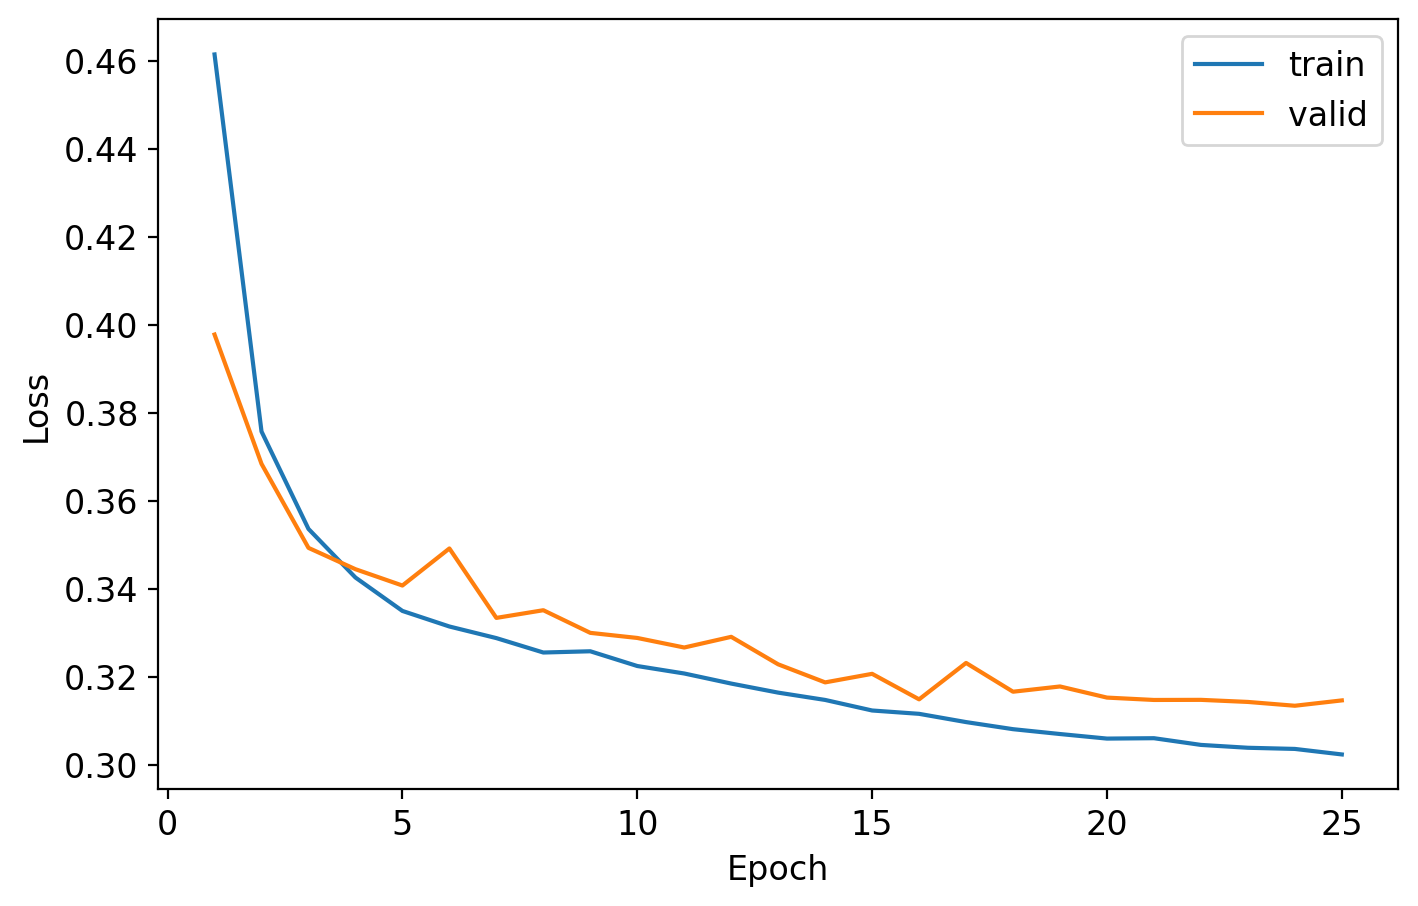

Epoch 25: train loss = 0.3023; valid loss = 0.3146


In [14]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 25, train_loader, valid_loader, criterion, device, scheduler=None)

In [15]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_true, y_prob))
print("F1 = %.4f" % f1_score(y_true, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_true, y_pred))
print("Precision = %.4f" % precision_score(y_true, y_pred))
print("Recall = %.4f" % recall_score(y_true, y_pred))

ROC-AUC = 0.9106
F1 = 0.6573
Accuracy = 0.8602
Precision = 0.7949
Recall = 0.5603


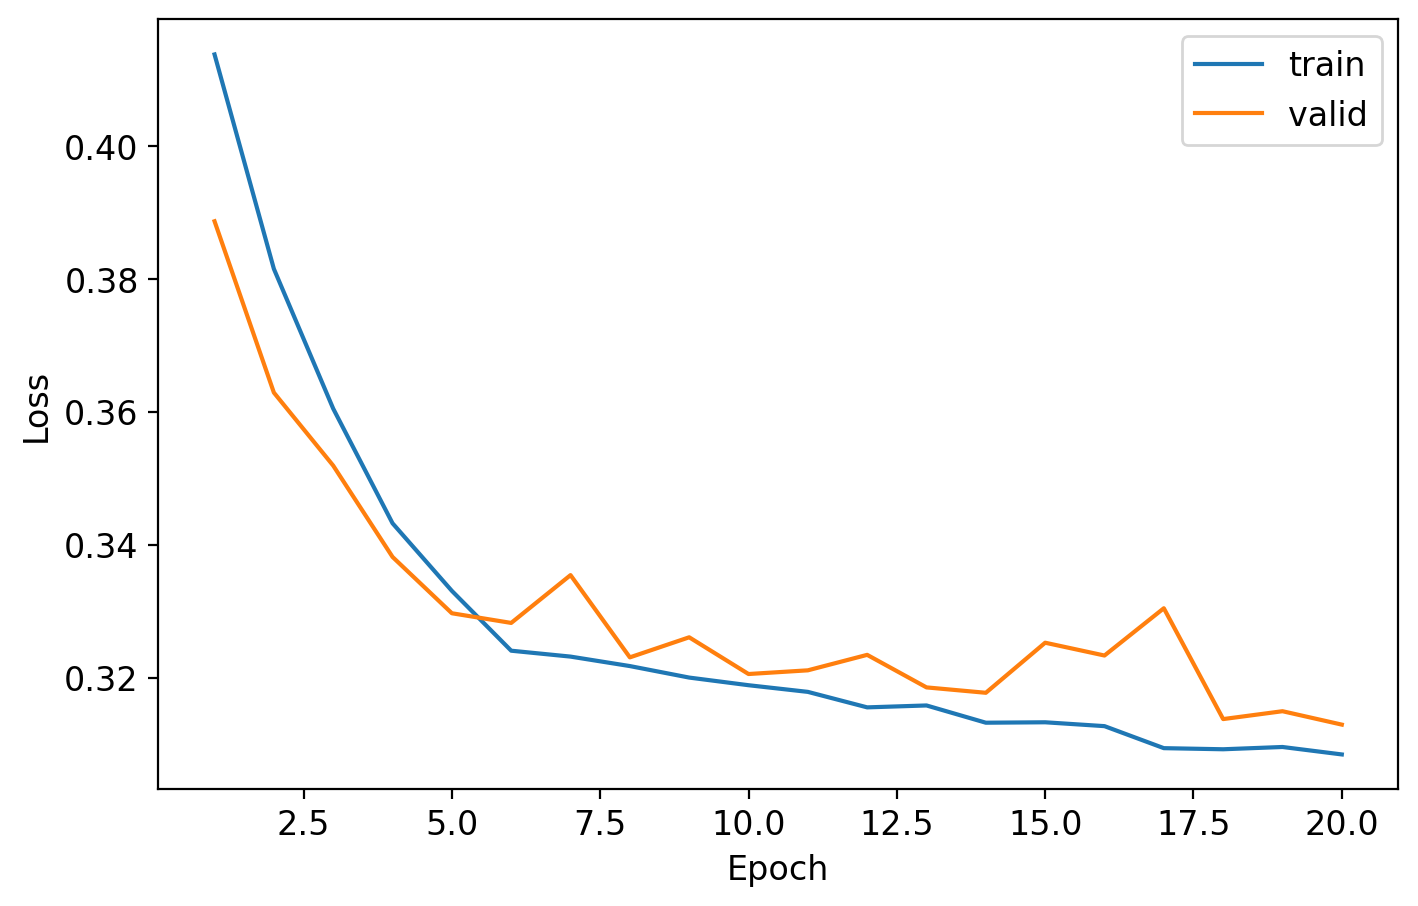

Epoch 20: train loss = 0.3084; valid loss = 0.3129


In [19]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 20, train_loader, valid_loader, criterion, device, scheduler=None)

In [20]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
print("ROC-AUC = %.4f" % roc_auc_score(y_true, y_prob))
print("F1 = %.4f" % f1_score(y_true, y_pred))
print("Accuracy = %.4f" % accuracy_score(y_true, y_pred))
print("Precision = %.4f" % precision_score(y_true, y_pred))
print("Recall = %.4f" % recall_score(y_true, y_pred))

ROC-AUC = 0.9136
F1 = 0.6902
Accuracy = 0.8583
Precision = 0.7239
Recall = 0.6595
